# Projeto GLM - Regressão Logística Binária - Lucas Malta
## Previsão de Regime Político a partir de Indicadores Socioeconômicos

Este projeto tem como objetivo construir um modelo de regressão logística (GLM binário) capaz de prever se um país possui um regime democrático ou não democrático, com base em indicadores socioeconômicos do Índice Global de Prosperidade de 2023.

A motivação teórica reside na ideia de que o desenvolvimento econômico e social está positivamente associado à democracia. Países com melhores indicadores de saúde, educação, segurança e liberdade individual tendem a manter instituições democráticas mais sólidas.

Variável dependente: construída a partir da classificação original de regimes políticos, sendo dicotomizada em:

1 = Democrático (Liberal democracy, Electoral democracy)

0 = Não democrático (Electoral autocracy, Closed autocracy)

Justificativa do modelo: A escolha da regressão logística binária (GLM com família Binomial e função de ligação Logit) se justifica pela natureza dicotômica da variável resposta.

Dados fonte disponíveis em: https://www.kaggle.com/datasets/aaronnorman/2023-global-prosperity-index-w-region-politics

---
## Carregamento de Bibliotecas

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, roc_auc_score
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

---
## Carregamento e Inspeção dos Dados

O dataset contém 159 países e 17 variáveis, incluindo indicadores de prosperidade em dimensões como segurança, liberdade pessoal, governança, saúde e educação.

Sobre a natureza dos dados: As variáveis numéricas representam posições dos paíeses em rankings 1 (1º lugar) = melhor desempenho no indicador. Isso significa que valores baixos indicam melhor performance entre as variáveis independentes.

In [ ]:
dados = pd.read_csv('global_prosperity_regions_politics.csv')
print(f"Dimensões do dataset: {dados.shape[0]} linhas x {dados.shape[1]} colunas")
dados.head()

Dimensões do dataset: 159 linhas x 17 colunas


,country,code,region,political_regime,average_score,safety_and_security,personal_freedom,governance,social_capital,investment_environment,enterprise_conditions,infrastructure_and_market_access,economic_quality,living_conditions,health,education,natural_environment
0,Denmark,DNK,Europe,Liberal democracy,6.00,6.0,2.0,3.0,1.0,8.0,8.0,9.0,7.0,2.0,16.0,5.0,5.0
1,Sweden,SWE,Europe,Liberal democracy,6.83,10.0,4.0,7.0,4.0,6.0,15.0,7.0,8.0,3.0,9.0,8.0,1.0
2,Norway,NOR,Europe,Liberal democracy,7.25,3.0,1.0,2.0,3.0,9.0,14.0,20.0,5.0,4.0,7.0,10.0,9.0
3,Finland,FIN,Europe,Liberal democracy,8.00,15.0,3.0,1.0,7.0,2.0,12.0,10.0,20.0,7.0,15.0,2.0,2.0
4,Switzerland,CHE,Europe,Liberal democracy,6.75,2.0,12.0,4.0,12.0,12.0,1.0,11.0,2.0,5.0,10.0,4.0,6.0


In [ ]:
# Verificação de tipos de dados e colunas disponíveis
print("Colunas disponíveis:")
print(dados.columns.tolist())
print()
print("Tipos de dados:")
print(dados.dtypes)

Colunas disponíveis:
['country', 'code', 'region', 'political_regime', 'average_score', 'safety_and_security', 'personal_freedom', 'governance', 'social_capital', 'investment_environment', 'enterprise_conditions', 'infrastructure_and_market_access', 'economic_quality', 'living_conditions', 'health', 'education', 'natural_environment']

Tipos de dados:
country                              object
code                                 object
region                               object
political_regime                     object
average_score                       float64
safety_and_security                 float64
personal_freedom                    float64
governance                          float64
social_capital                      float64
investment_environment              float64
enterprise_conditions               float64
infrastructure_and_market_access    float64
economic_quality                    float64
living_conditions                   float64
health                        

##Descrição dos dados

country: Nome do país.

code: Código ISO do país.

region: Região geográfica.

political_regime: Tipo de regime político.

safety_and_security: Grau de desestabilização da segurança devido a guerras, conflitos, terror e crime.

personal_freedom: Progresso em direitos legais, liberdades individuais e tolerância social.

governance: Extensão dos controles sobre o poder, eficácia do governo e ausência de corrupção.

social_capital: Força das relações pessoais/sociais, confiança institucional, normas sociais e participação cívica.

investment_environment: Proteção e acessibilidade aos investimentos.

enterprise_conditions: Regulamentações que facilitam a abertura, competição e expansão de negócios.

infrastructure_and_market_access:Qualidade da infraestrutura de comércio e das condições de acesso a mercados.

economic_quality: Geração sustentável de riqueza e engajamento da força de trabalho.

living_conditions: Qualidade de vida, incluindo recursos materiais, moradia, serviços básicos e conectividade.

health: Resultados de saúde, sistemas de saúde, fatores de risco/doenças e taxas de mortalidade.

education: Matrículas, resultados e qualidade nos níveis de educação e habilidades dos adultos.

natural_environment: Aspectos do ambiente físico que afetam a vida diária e a prosperidade futura.

average_score: Posição média geral.

---
## Processamento de Dados

Criação da Variável Dependente Binária

A variável original "political_regime" possui quatro categorias. Sendo assim, para aplicar a regressão logística binária, os dados serão divididos em:
- Democrático (1): Liberal democracy, Electoral democracy
- Não democrático (0): Electoral autocracy, Closed autocracy

Nota: regimes híbridos foram classificados como não democráticos, o que simplifica a análise ao custo de perder nuances entre diferentes graus de autoritarismo.

In [ ]:
print("Categorias originais de regime político:")
print(dados['political_regime'].value_counts())
print()

def map_political_regime(regime):
    if regime in ['Liberal democracy', 'Electoral democracy']:
        return 1  # Democrático
    elif regime in ['Electoral autocracy', 'Closed autocracy']:
        return 0  # Não democrático

dados['is_democratic'] = dados['political_regime'].apply(map_political_regime)

print("Distribuição da variável binária 'is_democratic':")
print(dados['is_democratic'].value_counts())
print()
print(f"Proporção democrático: {dados['is_democratic'].mean():.2%}")

Categorias originais de regime político:
political_regime
Electoral democracy    50
Electoral autocracy    48
Closed autocracy       32
Liberal democracy      29
Name: count, dtype: int64

Distribuição da variável binária 'is_democratic':
is_democratic
0    80
1    79
Name: count, dtype: int64

Proporção democrático: 49.69%


Classes balanceadas já que o dataset não possui problema de desbalanceamento.

### Seleção e Preparação das Variáveis Independentes

Selecionamos as 12 variáveis socioeconômicas disponíveis no dataset. Em seguida, forçamos a conversão para tipo numérico e removeu-se as amostras com dados ausentes.

In [ ]:
relevant_columns = [
    'safety_and_security',
    'personal_freedom',
    'governance',
    'social_capital',
    'investment_environment',
    'enterprise_conditions',
    'infrastructure_and_market_access',
    'economic_quality',
    'living_conditions',
    'health',
    'education',
    'natural_environment'
]

# Conversão para numérico
dados[relevant_columns] = dados[relevant_columns].apply(pd.to_numeric, errors='coerce')

# Remoção de valores ausentes
n_antes = len(dados)
dados = dados.dropna(subset=relevant_columns + ['is_democratic'])
n_depois = len(dados)

print(f"Observações antes da limpeza: {n_antes}")
print(f"Observações após remoção de NAs: {n_depois}")
print(f"Observações removidas: {n_antes - n_depois}")

Observações antes da limpeza: 159
Observações após remoção de NAs: 159
Observações removidas: 0


---
## Análise Descritiva

A análise descritiva fornece uma visão geral da distribuição das variáveis. Como as variáveis são rankings (1 = melhor), valores baixos indicam melhor desempenho. Espera-se que países democráticos estejam melhor posicionados no ranking segundo as teorias liberais.

In [ ]:
# Estatísticas descritivas gerais
print("Estatísticas descritivas das variáveis numéricas:")
dados[relevant_columns].describe().round(2)

Estatísticas descritivas das variáveis numéricas:


,safety_and_security,personal_freedom,governance,social_capital,investment_environment,enterprise_conditions,infrastructure_and_market_access,economic_quality,living_conditions,health,education,natural_environment
count,159.00,159.00,159.00,159.00,159.00,159.00,159.00,159.00,159.00,159.00,159.00,159.00
mean,84.43,84.65,83.93,82.99,82.69,83.42,82.27,82.58,82.52,82.81,82.44,84.21
std,48.39,48.92,48.55,48.73,48.32,48.49,48.20,48.03,48.31,47.98,48.09,49.45
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,42.50,41.50,42.00,40.50,41.50,41.50,41.50,41.50,41.50,41.50,41.50,40.50
50%,84.00,84.00,84.00,82.00,81.00,83.00,81.00,81.00,81.00,82.00,81.00,85.00
75%,126.50,127.50,125.50,125.50,125.50,125.50,124.50,123.00,123.50,123.50,123.50,127.50
max,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00


In [ ]:
# Comparação das médias por grupo (democrático vs. não democrático)
# Como os valores são rankings, médias menores indicam MELHOR desempenho
medias_por_grupo = dados.groupby('is_democratic')[relevant_columns].mean().round(2)
medias_por_grupo.index = ['Não democrático (0)', 'Democrático (1)']
print("Média dos rankings por grupo (valores menores = melhor desempenho):")
medias_por_grupo

Média dos rankings por grupo (valores menores = melhor desempenho):


,safety_and_security,personal_freedom,governance,social_capital,investment_environment,enterprise_conditions,infrastructure_and_market_access,economic_quality,living_conditions,health,education,natural_environment
Não democrático (0),109.62,123.86,116.89,107.45,110.80,109.74,107.60,104.54,107.02,104.42,106.64,114.65
Democrático (1),58.92,44.94,50.56,58.23,54.23,56.76,56.62,60.34,57.70,60.92,57.94,53.38


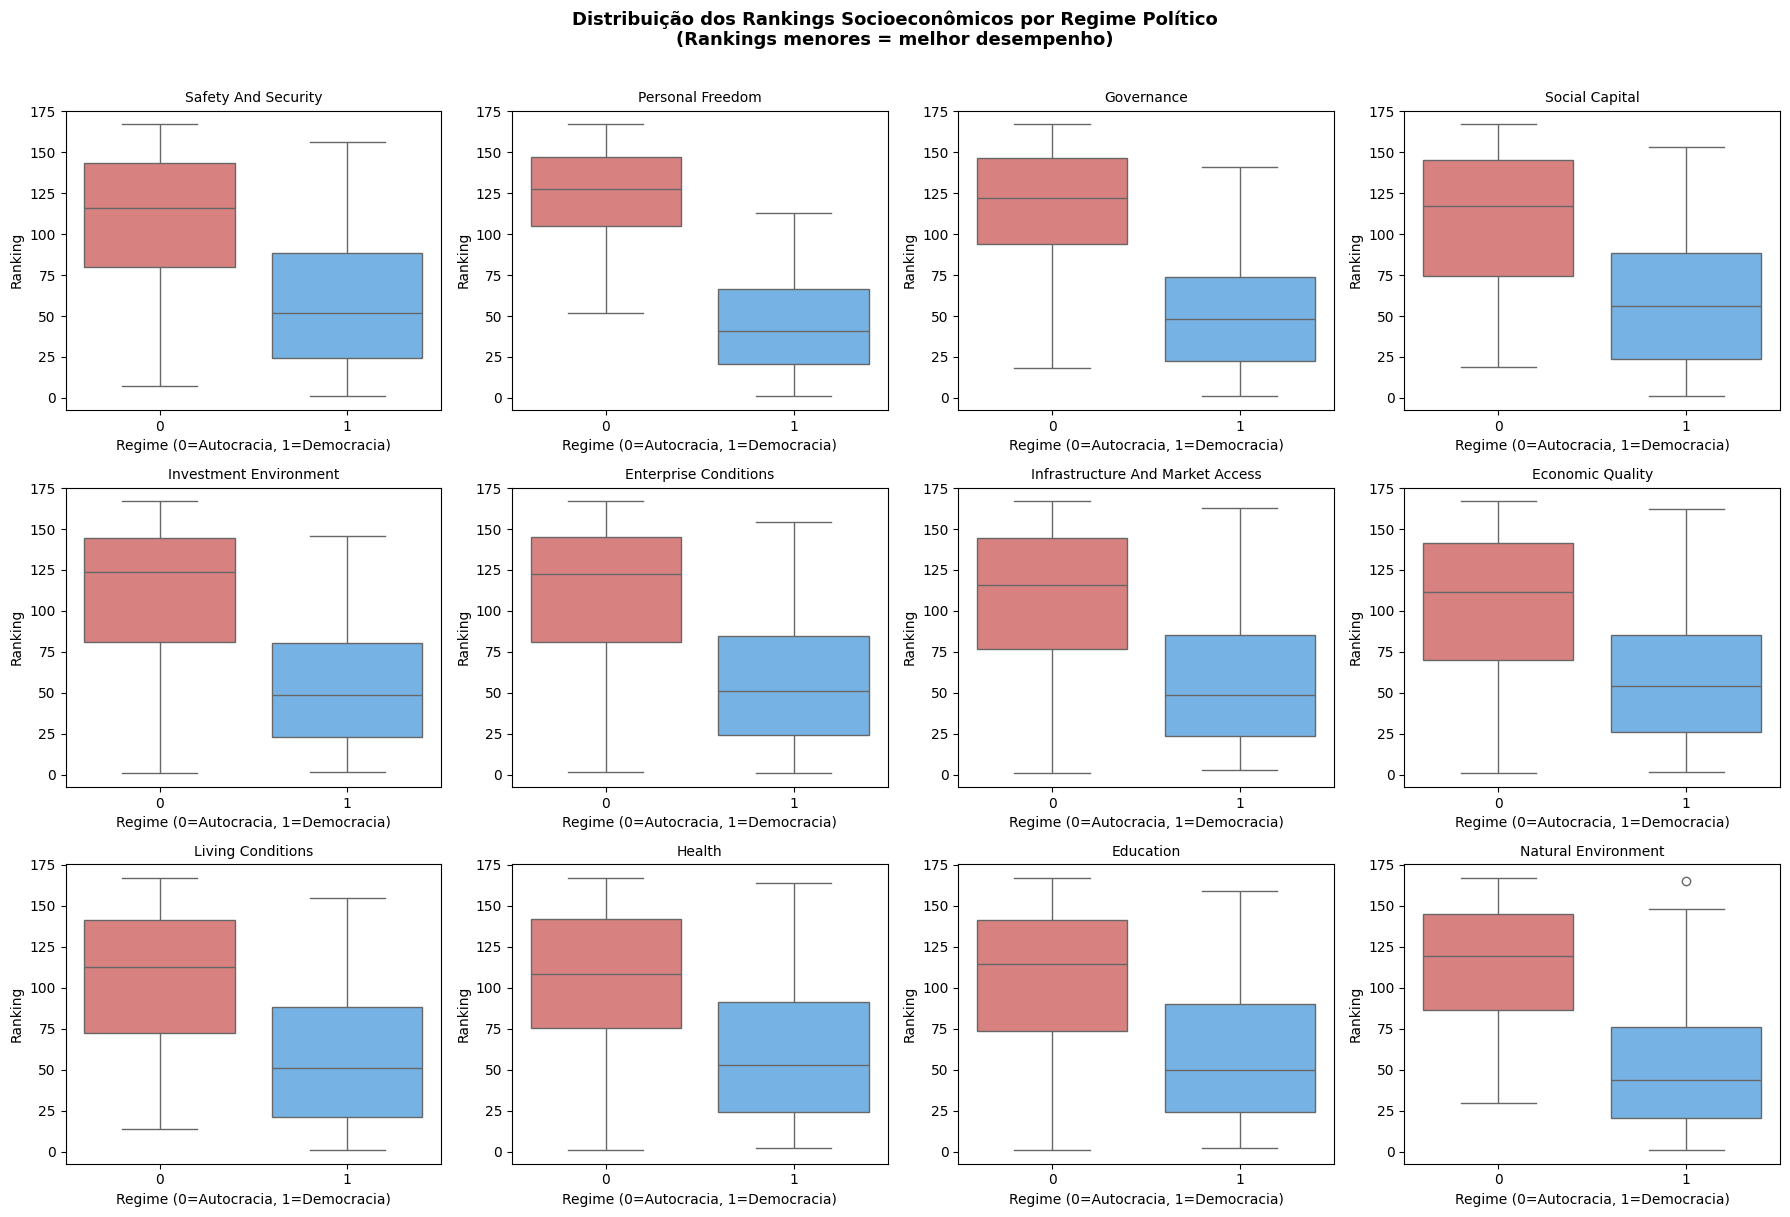

In [ ]:
# Visualização: boxplots comparativos por grupo
# Boxplots são mais informativos do que histogramas para comparar distribuições entre grupos
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(relevant_columns):
    sns.boxplot(
        data=dados, x='is_democratic', y=col, ax=axes[i],
        hue='is_democratic', # Adicionado para mapear corretamente a paleta
        palette={0: '#E57373', 1: '#64B5F6'},
        legend=False # Adicionado para evitar legendas duplicadas (sugestão do warning)
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_xlabel('Regime (0=Autocracia, 1=Democracia)')
    axes[i].set_ylabel('Ranking')

plt.suptitle('Distribuição dos Rankings Socioeconômicos por Regime Político\n(Rankings menores = melhor desempenho)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

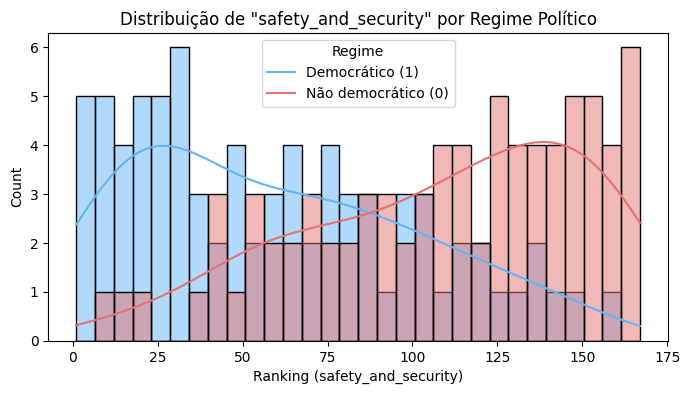

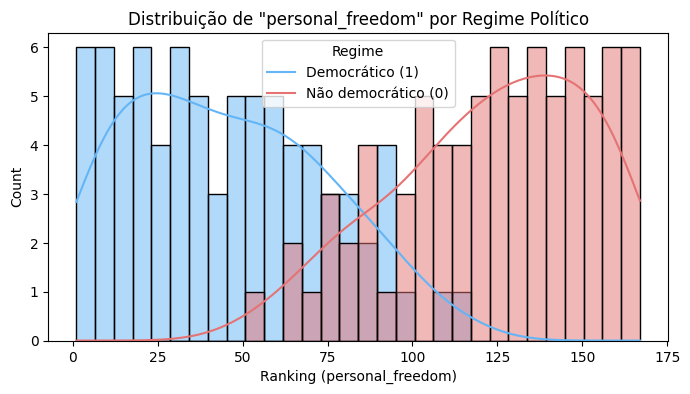

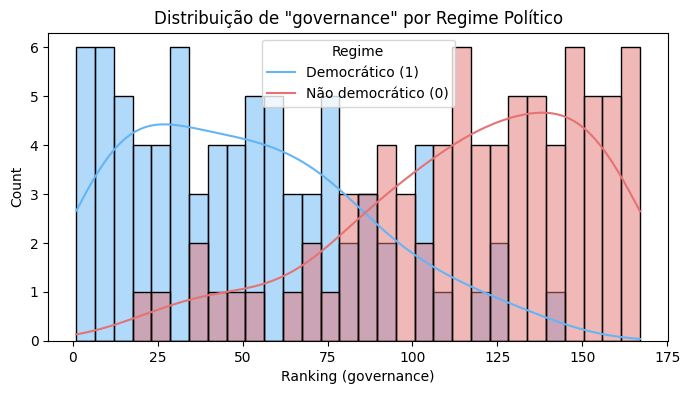

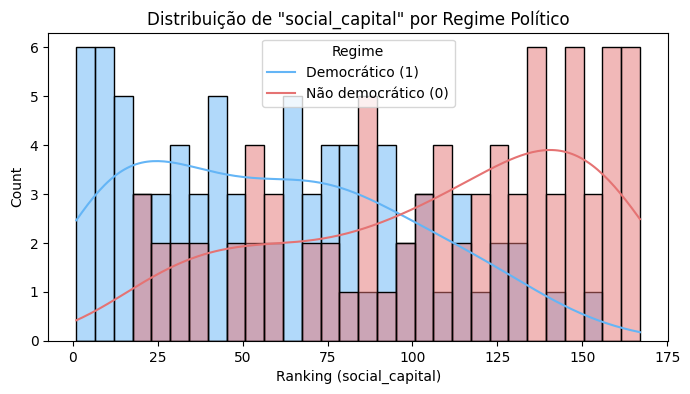

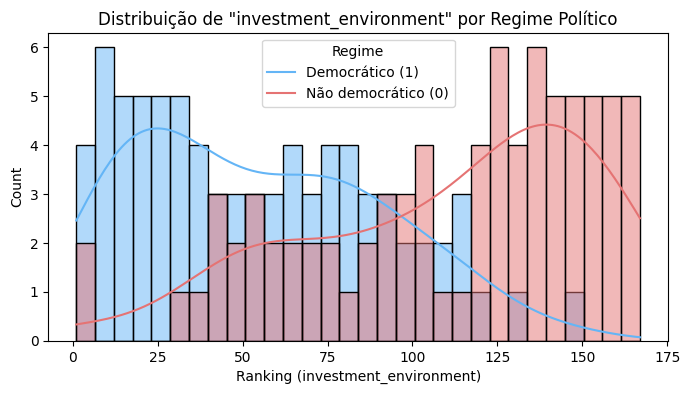

In [ ]:
# Histogramas com KDE por grupo para as 5 primeiras variáveis
for col in relevant_columns[:5]:
    plt.figure(figsize=(8, 4))
    sns.histplot(
        data=dados, x=col, hue='is_democratic', kde=True, bins=30,
        palette={0: '#E57373', 1: '#64B5F6'}
    )
    plt.title(f'Distribuição de "{col}" por Regime Político')
    plt.xlabel(f'Ranking ({col})')
    plt.legend(title='Regime', labels=['Democrático (1)', 'Não democrático (0)'])
    plt.show()

---
## Análise de Correlação

Matriz de Correlação

Analisamos as correlações entre as variáveis independentes e com a variável dependente.

OBS: Como as variáveis são rankings (posição na variável), um valor baixo significa melhor desempenho. Portanto, países democráticos, que tendem a ter melhores indicadores, apresentam rankings menores. Isso explica por que as correlações com "is_democratic" são Negativas uma vez que quanto melhor o indicador socioeconômico (posição menor), maior a probabilidade de democracia. Esse resultado é, portanto, esperado e teoricamente consistente.

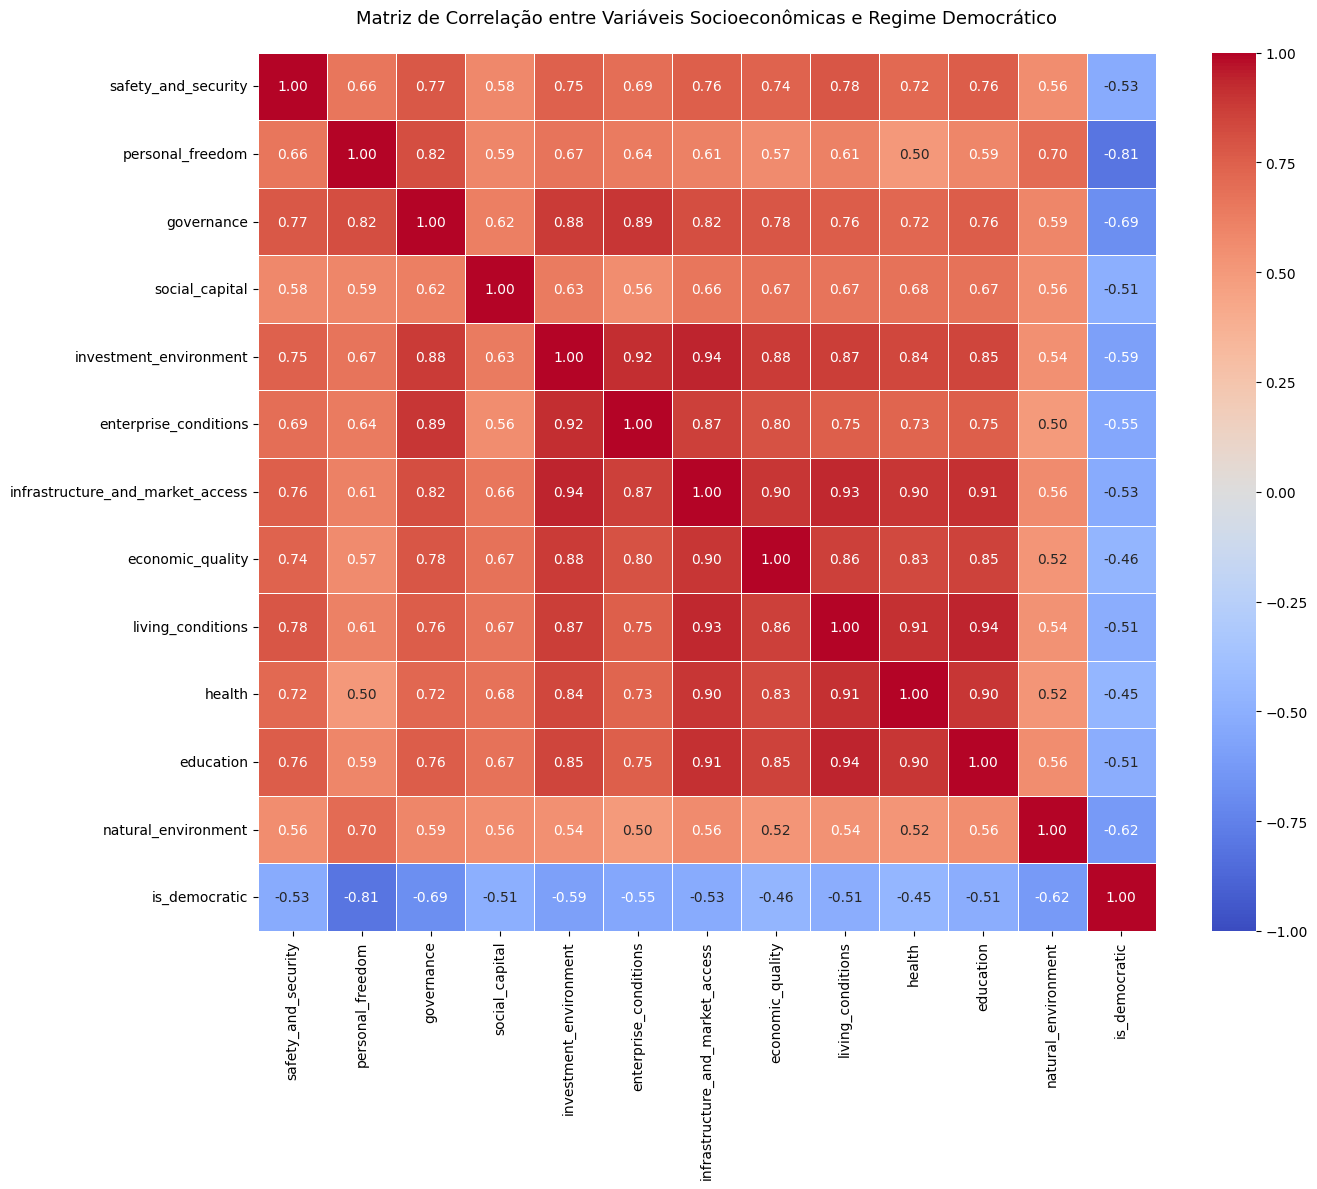

In [ ]:
cols_correlacao = relevant_columns + ['is_democratic']
corr_matrix = dados[cols_correlacao].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Matriz de Correlação entre Variáveis Socioeconômicas e Regime Democrático\n',
          fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Correlação específica com is_democratic
corr_com_alvo = corr_matrix['is_democratic'].drop('is_democratic').sort_values()

print("Correlação das variáveis com 'is_democratic' (ordenada do mais negativo ao menos negativo):")
print(corr_com_alvo.round(4))
print()
print("Interpretação das correlações:")
print("  Todas as correlações são negativas devido as variáveis indepndentes serem as posições dos países em um ranking.")
print("  países com um número menor no ranking em liberdade pessoal são os mais livres e assim tem maior correlação com regimes democráticos.")
print("  As variáveis com correlação mais forte (mais negativa) são portanto as com correlação mais forte.")

Correlação das variáveis com 'is_democratic' (ordenada do mais negativo ao menos negativo):
personal_freedom                   -0.8092
governance                         -0.6852
natural_environment                -0.6214
investment_environment             -0.5872
enterprise_conditions              -0.5480
infrastructure_and_market_access   -0.5305
safety_and_security                -0.5255
living_conditions                  -0.5121
education                          -0.5079
social_capital                     -0.5067
economic_quality                   -0.4616
health                             -0.4547
Name: is_democratic, dtype: float64

Interpretação das correlações:
  Todas as correlações são negativas devido as variáveis indepndentes serem as posições dos países em um ranking.
  países com um número menor no ranking em liberdade pessoal são os mais livres e assim tem maior correlação com regimes democráticos.
  As variáveis com correlação mais forte (mais negativa) são portanto as co

---
## Validação de Pressupostos

1 Fator de Inflação da Variância (VIF) — Diagnóstico de Multicolinearidade

A multicolinearidade ocorre quando variáveis preditoras são altamente correlacionadas entre si, inflando os erros padrão dos coeficientes e tornando as estimativas instáveis. O VIF quantifica esse problema:

VIF < 5: sem multicolinearidade

VIF entre 5 e 10: multicolinearidade moderada (atenção)

VIF > 10: multicolinearidade severa

In [ ]:
# Cálculo do VIF com todas as 12 variáveis
X_vif = dados[relevant_columns]
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Variável'] = X_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i)
                   for i in range(X_vif_const.shape[1])]
vif_data = vif_data[vif_data['Variável'] != 'const'].sort_values('VIF', ascending=False)
vif_data['Multicoliniaridade'] = vif_data['VIF'].apply(
    lambda v: ' Alta' if v > 10 else (' Moderada' if v > 5 else 'Baixa')
)

print("VIF inicial (todas as variáveis):")
print(vif_data.round(2).to_string(index=False))

VIF inicial (todas as variáveis):
                        Variável   VIF Multicoliniaridade
infrastructure_and_market_access 20.41               Alta
               living_conditions 16.83               Alta
          investment_environment 15.69               Alta
                      governance 13.16               Alta
                       education 10.98               Alta
           enterprise_conditions 10.40               Alta
                          health  8.26           Moderada
                economic_quality  6.17           Moderada
                personal_freedom  6.03           Moderada
             safety_and_security  3.43              Baixa
             natural_environment  2.49              Baixa
                  social_capital  2.37              Baixa


### Remoção de Variáveis com Alta Multicolinearidade

As variáveis com VIF > 10 serão removidas, pois indicam redundância informacional alta com outras variávis independente (não sendo assim realmente independentes). A variável "education" será mantida apesar do VIF elevado, por sua reconhecida relevância teórica na explicação de regimes políticos (investimento e nível educacional é um dos principais preditores de democracia na literatura).

Após a remoção, o VIF será recalculado para confirmar se o problema foi resolvido.

In [ ]:
# Variáveis com VIF > 10 a serem removidas (exceto education)
high_vif_to_remove = [
    'infrastructure_and_market_access',
    'living_conditions',
    'investment_environment',
    'governance',
    'enterprise_conditions'
]

keep_vars = [col for col in relevant_columns if col not in high_vif_to_remove]
print("Variáveis removidas por multicolinearidade severa:")
for v in high_vif_to_remove:
    print(f"  - {v}")
print()
print("Variáveis mantidas no modelo:")
for v in keep_vars:
    print(f"  + {v}")

Variáveis removidas por multicolinearidade severa:
  - infrastructure_and_market_access
  - living_conditions
  - investment_environment
  - governance
  - enterprise_conditions

Variáveis mantidas no modelo:
  + safety_and_security
  + personal_freedom
  + social_capital
  + economic_quality
  + health
  + education
  + natural_environment


In [ ]:
# Recálculo do VIF após remoção — verificação de que o problema foi resolvido
X_vif_reduzido = dados[keep_vars]
X_vif_reduzido_const = sm.add_constant(X_vif_reduzido)

vif_reduzido = pd.DataFrame()
vif_reduzido['Variável'] = X_vif_reduzido_const.columns
vif_reduzido['VIF'] = [variance_inflation_factor(X_vif_reduzido_const.values, i)
                       for i in range(X_vif_reduzido_const.shape[1])]
vif_reduzido = vif_reduzido[vif_reduzido['Variável'] != 'const'].sort_values('VIF', ascending=False)
vif_reduzido['Multicoleniaridade'] = vif_reduzido['VIF'].apply(
    lambda v: 'Alta' if v > 10 else ('Moderada' if v > 5 else 'Baixa')
)

print("VIF após remoção das variáveis problemáticas:")
print(vif_reduzido.round(2).to_string(index=False))
print()
print("A maioria das variáveis apresenta VIF aceitável. 'education' permanece com VIF moderado,")
print(" o que é tolerável dada sua relevância teórica.")

VIF após remoção das variáveis problemáticas:
           Variável  VIF Multicoleniaridade
          education 7.21           Moderada
             health 6.11           Moderada
   economic_quality 4.38              Baixa
safety_and_security 3.04              Baixa
   personal_freedom 2.74              Baixa
     social_capital 2.30              Baixa
natural_environment 2.20              Baixa

A maioria das variáveis apresenta VIF aceitável. 'education' permanece com VIF moderado,
 o que é tolerável dada sua relevância teórica.


---
## Ajuste do Modelo GLM Binomial (Modelo 1)

Divisão Treino/Teste e Ajuste

Dividimos os dados em 70% para treino e 30% para teste, com semente fixa para reprodutibilidade. O modelo é ajustado com statsmodels.GLM utilizando a família Binomial e função de ligação Logit, que é a configuração padrão da regressão logística.

In [ ]:
X = dados[keep_vars]
y = dados['is_democratic']

# Divisão treino/teste: 70% treino, 30% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Conjunto de treino: {X_train.shape[0]} observações")
print(f"Conjunto de teste:  {X_test.shape[0]} observações")
print(f"Proporção democrático no treino: {y_train.mean():.2%}")
print(f"Proporção democrático no teste:  {y_test.mean():.2%}")

Conjunto de treino: 111 observações
Conjunto de teste:  48 observações
Proporção democrático no treino: 49.55%
Proporção democrático no teste:  50.00%


In [ ]:
# Adicionar constante (intercepto) e ajustar o modelo
X_train_const = sm.add_constant(X_train)

modelo_glm = sm.GLM(
    y_train,
    X_train_const,
    family=sm.families.Binomial()  # família Binomial com link Logit (padrão)
)

resultado = modelo_glm.fit()

print(resultado.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          is_democratic   No. Observations:                  111
Model:                            GLM   Df Residuals:                      103
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18.458
Date:                Wed, 25 Mar 2026   Deviance:                       36.915
Time:                        23:57:27   Pearson chi2:                     41.4
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6513
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  10.0571    

Ajuste do modelo: Utilizou-se o método IRLS (Iteratively Reweighted Least Squares) com 111 observações de treino e 7 graus de liberdade do modelo. A convergência foi alcançada em 8 iterações, e a escala fixada em 1,0 confirma a ausência de superdispersão (adequado para a família Binomial).

Preditores significativos: As variáveis personal_freedom (z = −4,025; p < 0,001) e natural_environment (z = −2,259; p = 0,024) apresentaram significância estatística.

Direção dos efeitos: Ambas possuem coeficientes negativos, indicando que piores posições nos rankings (menor liberdade pessoal e pior qualidade ambiental) estão associadas a menores chances de o país ser democrático.

Preditores não significativos: As demais cinco variáveis (safety_and_security, social_capital, economic_quality, health, education) não atingiram significância individual (p > 0,05). Seus intervalos de confiança cruzam o zero, sugerindo que sua contribuição marginal não é distinta de zero dado o conjunto de preditores já incluído.

### Pseudo R² e Qualidade de Ajuste Geral

Diferentemente da regressão linear, o GLM binomial não possui um R² convencional. Utilizamos o Pseudo R² de McFadden, que compara a log-verossimilhança do modelo ajustado com a de um modelo nulo (apenas intercepto):

Valores entre 0,2 e 0,4 são considerados bons para modelos logísticos e > 0,40 são considerados ótimos.

In [ ]:
# Pseudo R² de McFadden
ll_modelo = resultado.llf       # log-verossimilhança do modelo ajustado
ll_nulo   = resultado.llnull    # log-verossimilhança do modelo nulo

pseudo_r2_mcfadden = 1 - (ll_modelo / ll_nulo)

# AIC e BIC
aic = resultado.aic
bic = resultado.bic_llf

# Deviance e graus de liberdade
deviance = resultado.deviance
df_resid = resultado.df_resid

print("=== Métricas de Qualidade de Ajuste (Modelo 1 — GLM) ===")
print(f"Log-verossimilhança do modelo:  {ll_modelo:.4f}")
print(f"Log-verossimilhança do modelo nulo: {ll_nulo:.4f}")
print(f"Pseudo R² de McFadden:          {pseudo_r2_mcfadden:.4f}")
print(f"AIC:                            {aic:.4f}")
print(f"BIC:                            {bic:.4f}")
print(f"Deviance residual:              {deviance:.4f}")
print(f"Graus de liberdade residual:    {df_resid}")
print()
print("  0,10–0,20 = aceitável | 0,20–0,40 = bom | > 0,40 = [ótimo]")

=== Métricas de Qualidade de Ajuste (Modelo 1 — GLM) ===
Log-verossimilhança do modelo:  -18.4576
Log-verossimilhança do modelo nulo: -76.9348
Pseudo R² de McFadden:          0.7601
AIC:                            52.9151
BIC:                            74.5914
Deviance residual:              36.9151
Graus de liberdade residual:    103

  0,10–0,20 = aceitável | 0,20–0,40 = bom | > 0,40 = [ótimo]


O modelo obteve Pseudo R² = 0,76, valor considerado ótimo e que indica excelente capacidade preditiva em relação ao modelo nulo.

Esse resultado indica que o modelo com os 7 preditores explica uma proporção muito expressiva da variância em relação ao modelo nulo, com a log-verossimilhança passando de −76,93 (nulo) para −18,46 (modelo ajustado).

### Interpretação dos Coeficientes: Odds Ratios

Os coeficientes do modelo logístico representam a variação no log-odds de ser democrático para cada unidade de aumento no preditor. Para facilitar a interpretação substantiva, calculamos as Odds Ratios (OR = e^β):

OR > 1: aumento no preditor está associado a maior chance de democracia
OR < 1: aumento no preditor está associado a menor chance de democracia
OR = 1: preditor sem efeito sobre a chance de democracia

OBS: como as variáveis são rankings, um aumento de 1 unidade = piora de uma posição no ranking. Portanto, OR < 1 para um ranking significa que pior posição logo menor chance de democracia.

In [ ]:
# Odds Ratios com intervalos de confiança de 95%
coefs = resultado.params
ic_95 = resultado.conf_int(alpha=0.05)  # intervalo de confiança 95%
pvalores = resultado.pvalues

tabela_or = pd.DataFrame({
    'Coeficiente (β)': coefs,
    'Odds Ratio (e^β)': np.exp(coefs),
    'IC 95% Inferior': np.exp(ic_95.iloc[:, 0]),
    'IC 95% Superior': np.exp(ic_95.iloc[:, 1]),
    'p-valor': pvalores
})

tabela_or['Significancia'] = tabela_or['p-valor'].apply(
    lambda p: 'Alta' if p < 0.001 else ('Boa' if p < 0.01 else ('Baixa' if p < 0.05 else 'não.sig.'))
)

print("Coeficientes e Odds Ratios do Modelo 1:")
print(tabela_or.round(4).to_string())

Coeficientes e Odds Ratios do Modelo 1:
                     Coeficiente (β)  Odds Ratio (e^β)  IC 95% Inferior  IC 95% Superior  p-valor Significancia
const                        10.0571        23320.7496         132.7199     4.097782e+06   0.0001          Alta
safety_and_security           0.0111            1.0111           0.9816     1.041600e+00   0.4646      não.sig.
personal_freedom             -0.0761            0.9267           0.8930     9.617000e-01   0.0001          Alta
social_capital               -0.0024            0.9977           0.9712     1.024800e+00   0.8637      não.sig.
economic_quality              0.0316            1.0321           0.9930     1.072800e+00   0.1090      não.sig.
health                       -0.0251            0.9752           0.9315     1.021000e+00   0.2833      não.sig.
education                    -0.0182            0.9820           0.9318     1.034900e+00   0.4976      não.sig.
natural_environment          -0.0372            0.9634          

A tabela de odds ratios aprsenta os coeficientes do modelo para uma escala de razão de chances, mais intuitiva para interpretação substantiva.

personal_freedom é o preditor de maior impacto e significância (OR = 0,927; p < 0,001): cada piora de uma posição no ranking de liberdade pessoal está associada a uma redução de aproximadamente 7,3% na chance de o país ser democrático, com intervalo de confiança de 95% inteiramente abaixo de 1 (0,893; 0,962).

natural_environment é o segundo preditor significativo (OR = 0,963; p = 0,024), com redução de 3,7% na chance de democracia por posição perdida no ranking ambiental.

Ambas abaixo de 1 (representação gráfica abaixo)

Já as demais variáveis apresentam odds ratios próximas de 1 e intervalos de confiança que cruzam esse valor, confirmando ausência de efeito individual significativo.  

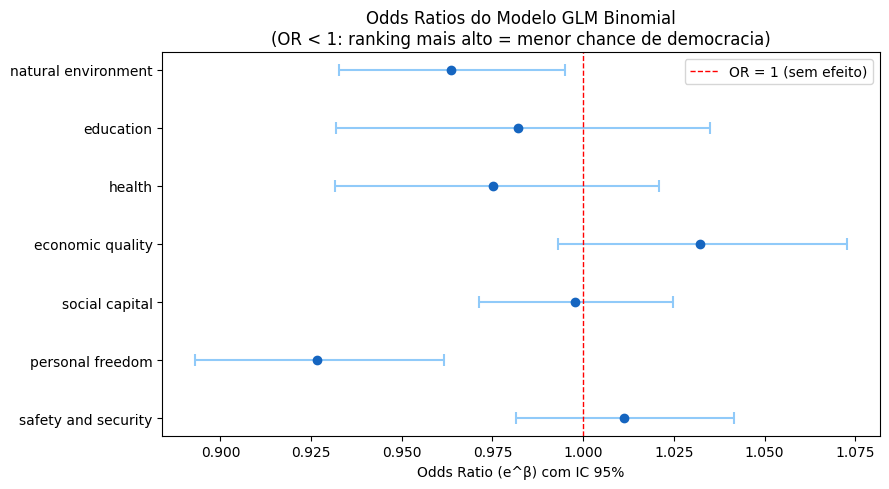

In [ ]:
# Visualização dos Odds Ratios com intervalos de confiança
tabela_or_sem_const = tabela_or.drop('const')

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = range(len(tabela_or_sem_const))

ax.errorbar(
    tabela_or_sem_const['Odds Ratio (e^β)'],
    y_pos,
    xerr=[
        tabela_or_sem_const['Odds Ratio (e^β)'] - tabela_or_sem_const['IC 95% Inferior'],
        tabela_or_sem_const['IC 95% Superior'] - tabela_or_sem_const['Odds Ratio (e^β)']
    ],
    fmt='o', color='#1565C0', ecolor='#90CAF9', capsize=4, capthick=1.5
)

ax.axvline(x=1, color='red', linestyle='--', linewidth=1, label='OR = 1 (sem efeito)')
ax.set_yticks(y_pos)
ax.set_yticklabels([v.replace('_', ' ') for v in tabela_or_sem_const.index])
ax.set_xlabel('Odds Ratio (e^β) com IC 95%')
ax.set_title('Odds Ratios do Modelo GLM Binomial\n(OR < 1: ranking mais alto = menor chance de democracia)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Avaliação do Modelo — Métricas de Desempenho

Previsões no Conjunto de Teste:

Utilizou-se o modelo ajustado para prever a probabilidade de democracia para cada país no conjunto de teste. Com ponto de corte em 0,5, classificamos como democrático (1) ou não democrático (0).

In [ ]:
# Previsões no conjunto de teste
X_test_const = sm.add_constant(X_test)

y_pred_prob = resultado.predict(X_test_const)  # probabilidades previstas
y_pred = (y_pred_prob > 0.5).astype(int)        # classificação com corte em 0.5

print("Primeiras 10 previsões:")
preview = pd.DataFrame({
    'Prob. Democracia': y_pred_prob.values[:10].round(3),
    'Previsto': y_pred.values[:10],
    'Real': y_test.values[:10]
})
print(preview.to_string(index=False))

Primeiras 10 previsões:
 Prob. Democracia  Previsto  Real
            1.000         1     1
            0.193         0     1
            0.686         1     1
            0.000         0     0
            0.013         0     0
            0.854         1     1
            0.844         1     1
            0.500         0     0
            0.903         1     0
            0.001         0     0


### Matriz de Confusão e Métricas de Classificação

A matriz de confusão mostra os acertos e erros por classe. As métricas derivadas são:
- Acurácia: proporção de classificações corretas
- Precisão: dos classificados como democráticos, quantos realmente são
- Recall (sensibilidade): dos realmente democráticos, quantos foram identificados
- F1-score: média harmônica entre precisão e recall

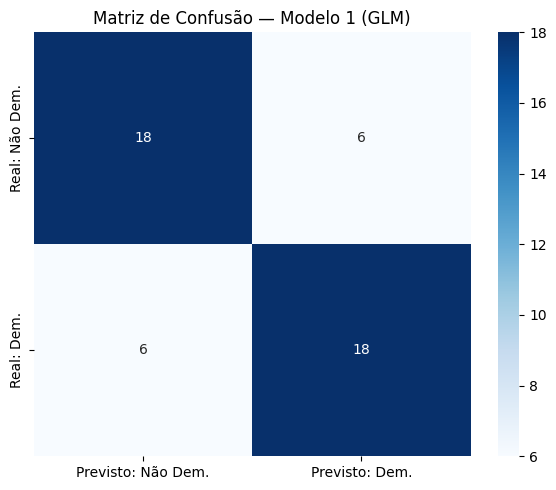

                 precision    recall  f1-score   support

Não Democrático       0.75      0.75      0.75        24
    Democrático       0.75      0.75      0.75        24

       accuracy                           0.75        48
      macro avg       0.75      0.75      0.75        48
   weighted avg       0.75      0.75      0.75        48

Acurácia geral: 0.7500


In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Previsto: Não Dem.', 'Previsto: Dem.'],
    yticklabels=['Real: Não Dem.', 'Real: Dem.']
)
plt.title('Matriz de Confusão — Modelo 1 (GLM)')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Não Democrático', 'Democrático']))
print(f"Acurácia geral: {accuracy_score(y_test, y_pred):.4f}")

### Curva ROC e AUC

A Curva ROC (Receiver Operating Characteristic) avalia a capacidade discriminatória do modelo em todos os possíveis pontos de corte. A AUC (Area Under the Curve) resume essa capacidade em um único número:

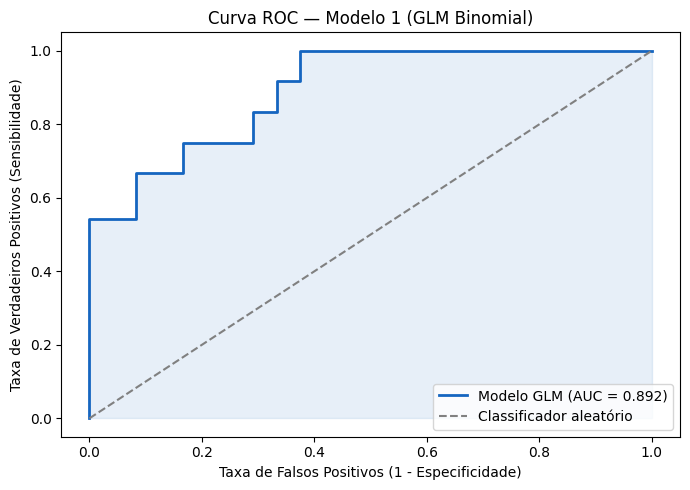

AUC = 0.8924
Poder discriminatório bom.


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1565C0', linewidth=2, label=f'Modelo GLM (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Classificador aleatório')
plt.fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
plt.title('Curva ROC — Modelo 1 (GLM Binomial)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC = {auc_score:.4f}")
if auc_score > 0.9:
    print("Poder discriminatório ótimo.")
elif auc_score > 0.8:
    print("Poder discriminatório bom.")
else:
    print("Verificar modelo - Poder discriminatório abaixo do desejado.")

---
## Análise de Resíduos e Diagnóstico do Modelo

- Resíduos Deviance e de Pearson — Visualização


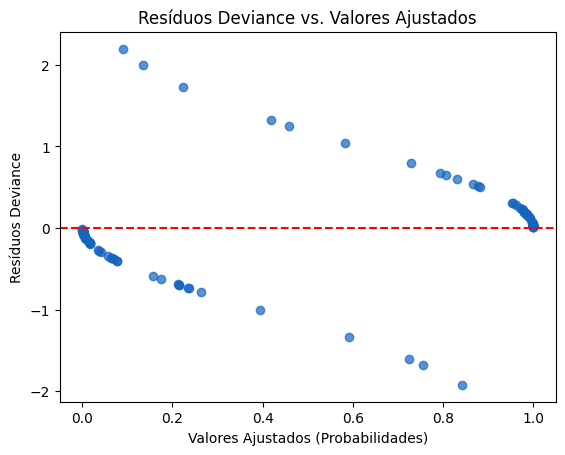

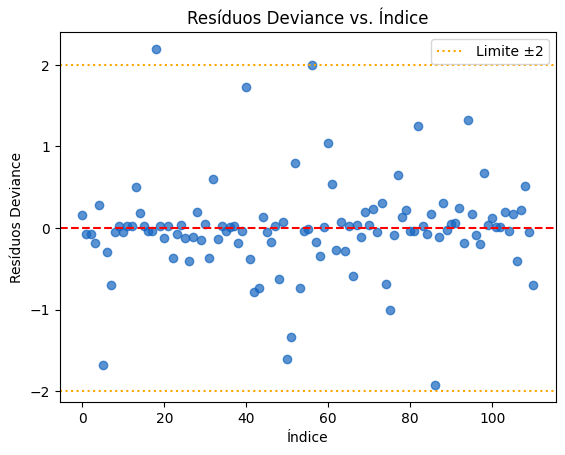

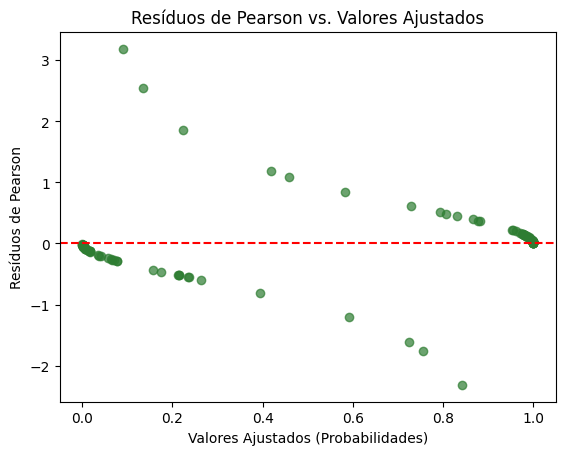

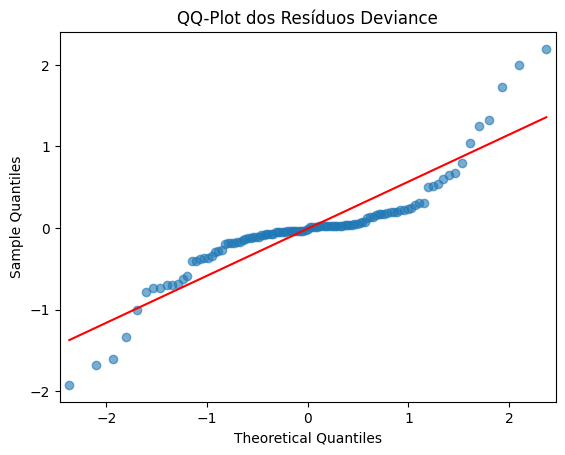

Outliers por Deviance   (|res| > 2): [18 56]
Outliers por Pearson    (|res| > 2): [18 56 86]
Total outliers Deviance: 2 (1.8% do treino)


In [ ]:
# Resíduos Deviance e de Pearson
residuos_deviance = resultado.resid_deviance
residuos_pearson  = resultado.resid_pearson
valores_ajustados = resultado.fittedvalues   # probabilidades ajustadas no treino

# --- Gráfico 1: Resíduos Deviance vs. Valores Ajustados (como na referência da disciplina)
plt.scatter(valores_ajustados, residuos_deviance, alpha=0.7, color='#1565C0')
plt.axhline(0, color='red', linestyle='--')
plt.title("Resíduos Deviance vs. Valores Ajustados")
plt.xlabel("Valores Ajustados (Probabilidades)")
plt.ylabel("Resíduos Deviance")
plt.show()

# --- Gráfico 2: Resíduos Deviance vs. Índice
plt.scatter(range(len(residuos_deviance)), residuos_deviance, alpha=0.7, color='#1565C0')
plt.axhline(0, color='red', linestyle='--')
plt.axhline( 2, color='orange', linestyle=':', label='Limite ±2')
plt.axhline(-2, color='orange', linestyle=':')
plt.xlabel('Índice')
plt.ylabel('Resíduos Deviance')
plt.title('Resíduos Deviance vs. Índice')
plt.legend()
plt.show()

# --- Gráfico 3: Resíduos de Pearson vs. Valores Ajustados
plt.scatter(valores_ajustados, residuos_pearson, alpha=0.7, color='#2E7D32')
plt.axhline(0, color='red', linestyle='--')
plt.title("Resíduos de Pearson vs. Valores Ajustados")
plt.xlabel("Valores Ajustados (Probabilidades)")
plt.ylabel("Resíduos de Pearson")
plt.show()

# --- Gráfico 4: QQ-Plot dos Resíduos Deviance
sm.qqplot(residuos_deviance, line='s', alpha=0.6)
plt.title('QQ-Plot dos Resíduos Deviance')
plt.show()

# Observações com resíduo grande (potenciais outliers/alavancagem)
grandes_dev = np.where(np.abs(residuos_deviance) > 2)[0]
grandes_pea = np.where(np.abs(residuos_pearson)  > 2)[0]
print(f"Outliers por Deviance   (|res| > 2): {grandes_dev}")
print(f"Outliers por Pearson    (|res| > 2): {grandes_pea}")
print(f"Total outliers Deviance: {len(grandes_dev)} ({len(grandes_dev)/len(residuos_deviance):.1%} do treino)")


 Resíduos Deviance vs. Valores Ajustados

 A distribuição dos resíduos stá dntro do prevista para regressões binárias, com acumulo e dispersão em áreas parelhas.

Resíduos Deviance vs. Índice

A grande maioria dos pontos se concentra dentro do intervalo de referência ±2 (linhas laranjas tracejadas), com  poucos pontos atípicos

Resíduos de Pearson vs. Valores Ajustados
O gráfico de resíduos de Pearson apresenta estrutura semelhante ao do deviance, sendo dois agrupamentos simétricos e ausência de padrões sistemáticos.

QQ-Plot dos Resíduos Deviance

O QQ-plot compara a distribuição empírica dos resíduos deviance com a distribuição normal teórica. Na regressão logística binária, normalidade dos resíduos não é um pressuposto do modelo, oque difere da regressão linear, portanto afastamentos da diagonal não indicam violação, indicam valores extremos semelhante aos observados nos outros gráficos.

### Deviance Residuals — Teste de Qualidade de Ajuste

Hipótese:

-   $H_0$: O modelo ajusta bem os dados.

-   $H_a$: O modelo não ajusta bem os dados.

Condição de Aceitação/Rejeição da Hipótese:

-   Não rejeita-se $H_0$: Se o valor $p$ calculado a partir da deviance é maior que $\alpha$, aceita-se $H_0$ e concluí-se que o modelo ajusta bem os dados.

-   Rejeitase $H_0$: Se o valor $p$ é menor que $\alpha$, rejeita-se $H_0$ e concluí-se que o modelo não ajusta bem os dados.


In [ ]:
# Teste de Deviance para os Resíduos
deviance_test_statistic = resultado.deviance
deviance_df             = resultado.df_resid
deviance_p_value        = 1 - stats.chi2.cdf(deviance_test_statistic, deviance_df)

print("Teste de Deviance para os Resíduos:")
print("Estatística de teste:", deviance_test_statistic)
print("Graus de liberdade:  ", deviance_df)
print("Valor p:             ", deviance_p_value)
print()
if deviance_p_value > 0.05:
    print("Conclusão (α=0,05): Não rejeitamos H₀ — o modelo ajusta bem os dados.")
else:
    print("Conclusão (α=0,05): Rejeitamos H₀ — há evidência de falta de ajuste.")


Teste de Deviance para os Resíduos:
Estatística de teste: 36.91511435483735
Graus de liberdade:   103
Valor p:              0.9999999997860938

Conclusão (α=0,05): Não rejeitamos H₀ — o modelo ajusta bem os dados.


### Pearson Chi-Square Test — Teste de Qualidade de Ajuste

Hipótese Testada:

-   $H_0$: O modelo ajusta bem os dados.

-   $H_a$: O modelo não ajusta bem os dados.

Condição de Aceitação/Rejeição:
-   Não rejeita-se $H_0$: Se o valor $p$ é maior que $\alpha$, aceitamos $H_0$ e concluímos que o modelo ajusta bem os dados.

-   Rejeita-se $H_0$: Se o valor $p$ é menor que $\alpha$, rejeitamos $H_0$ e concluímos que o modelo não ajusta bem os dados.


In [ ]:
# Obtendo os resíduos de Pearson
residuos_pearson = resultado.resid_pearson

# Teste de Pearson para os Resíduos
pearson_test_statistic = np.sum(residuos_pearson**2)
pearson_df             = len(residuos_pearson) - resultado.df_model - 1  # graus de liberdade corrigidos
pearson_p_value        = 1 - stats.chi2.cdf(pearson_test_statistic, pearson_df)

print("\nTeste de Pearson para os Resíduos:")
print("Estatística de teste:", pearson_test_statistic)
print("Graus de liberdade:  ", pearson_df)
print("Valor p:             ", pearson_p_value)
print()
if pearson_p_value > 0.05:
    print("Conclusão (α=0,05): Não rejeitamos H₀ - o modelo ajusta bem os dados.")
else:
    print("Conclusão (α=0,05): Rejeitamos H₀ - há evidência de falta de ajuste.")



Teste de Pearson para os Resíduos:
Estatística de teste: 41.366516435295125
Graus de liberdade:   103
Valor p:              0.9999999913218235

Conclusão (α=0,05): Não rejeitamos H₀ - o modelo ajusta bem os dados.


### Teste de Razão de Verossimilhança — Comparação com o Modelo Nulo

O Teste de Razão de Verossimilhança avalia se o modelo com preditores é significativamente melhor do que um modelo nulo (apenas com o intercepto). Em outras palavras, testa se as variáveis independentes conjuntamente contribuem para explicar o regime político.

Hipótese Testada:

-   $H_0$: O modelo com preditores não melhora significativamente o ajuste em relação ao modelo nulo (os coeficientes de todas as variáveis são iguais a zero).

-   $H_a$: O modelo com preditores melhora significativamente o ajuste — ao menos um coeficiente é diferente de zero.

Condição de Aceitação/Rejeição:
- Não rejeita-se $H_0$: valor $p > \alpha$ — as variáveis não contribuem.

- Rejeita-se $H_0$: valor $p \leq \alpha$ — o modelo é significativamente melhor que o nulo.


In [ ]:
# Ajustar o modelo nulo (apenas intercepto) sobre o mesmo conjunto de treino
X_nulo = sm.add_constant(np.ones(len(y_train)))
modelo_nulo = sm.GLM(y_train, X_nulo, family=sm.families.Binomial()).fit()

# Estatística do Teste de Razão de Verossimilhança
diff_ll = resultado.llf - modelo_nulo.llf          # diferença nas log-verossimilhanças
df_lrt  = resultado.df_model - modelo_nulo.df_model  # graus de liberdade adicionais
p_value_lrt = 1 - stats.chi2.cdf(2 * diff_ll, df_lrt)

print("Teste de Razão de Verossimilhança (Modelo 1 vs. Modelo Nulo):")
print("Log-verossimilhança Modelo 1:  ", round(resultado.llf,  4))
print("Log-verossimilhança Nulo:      ", round(modelo_nulo.llf, 4))
print("Estatística de teste (2*ΔLL):  ", round(2 * diff_ll, 4))
print("Graus de liberdade:            ", df_lrt)
print("Valor p:                       ", round(p_value_lrt, 6))
print()
if p_value_lrt < 0.05:
    print("Conclusão (α=0,05): Rejeitamos H₀ — o Modelo 1 é significativamente")
    print("melhor que o modelo nulo. As variáveis independentes contribuem")
    print("conjuntamente para prever o regime político.")
else:
    print("Conclusão (α=0,05): Não rejeitamos H₀ — o modelo não melhora")
    print("significativamente em relação ao nulo.")


Teste de Razão de Verossimilhança (Modelo 1 vs. Modelo Nulo):
Log-verossimilhança Modelo 1:   -18.4576
Log-verossimilhança Nulo:       -76.9348
Estatística de teste (2*ΔLL):   116.9546
Graus de liberdade:             7
Valor p:                        0.0

Conclusão (α=0,05): Rejeitamos H₀ — o Modelo 1 é significativamente
melhor que o modelo nulo. As variáveis independentes contribuem
conjuntamente para prever o regime político.


### Comparação de Modelos via AIC

Além do Teste de Raão de Verossimelhança, o AIC oferece comparar modelos também. O modelo com menor AIC é preferível, pois equilibra qualidade de ajuste e parcimônia (penaliza modelos mais complexos).

In [ ]:
# Comparação de AIC entre Modelo 1 e Modelo Nulo
print("Comparação de AIC:")
print(f"  Modelo Nulo (apenas intercepto): AIC = {modelo_nulo.aic:.4f}")
print(f"  Modelo 1   (7 preditores):       AIC = {resultado.aic:.4f}")
print(f"  Diferença (ΔAIC):                {modelo_nulo.aic - resultado.aic:.4f}")
print()
if modelo_nulo.aic - resultado.aic > 2:
    print("Conclusão: O Modelo 1 tem AIC substancialmente menor — preferível ao modelo nulo.")
else:
    print("Conclusáo: A diferença de AIC não é substancial.")

Comparação de AIC:
  Modelo Nulo (apenas intercepto): AIC = 155.8697
  Modelo 1   (7 preditores):       AIC = 52.9151
  Diferença (ΔAIC):                102.9546

Conclusão: O Modelo 1 tem AIC substancialmente menor — preferível ao modelo nulo.


---
## Modelo 2 — Regressão Logística com Regularização Lasso

Motivação e Diferenças em Relação ao Modelo 1

O Lasso aplica a penalidade (L1) aos coeficientes, forçando alguns deles a 0. Isso cria uma seleção automática de variáveis, sendo útil quando há muitos preditores potencialmente redundantes.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

# Usar todas as 12 variáveis
X_all = dados[relevant_columns]
y_all = dados['is_democratic']

# Divisão treino/teste com estratificação
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, stratify=y_all
)

# Padronização:garante que a penalidade seja aplicada igualmente a todas as variáveis)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled  = scaler.transform(X_test_all)  # usa média e dp do treino

print(f"Treino: {X_train_all.shape[0]} obs | Teste: {X_test_all.shape[0]} obs")
print("Padronização aplicada: média ≈ 0, desvio padrão ≈ 1 para cada variável.")

Treino: 111 obs | Teste: 48 obs
Padronização aplicada: média ≈ 0, desvio padrão ≈ 1 para cada variável.


### Ajuste do Modelo Lasso com Validação Cruzada

Utilizou-se o LogisticRegressionCV que testa 10 valores de C automaticamente e seleciona aquele que maximiza a AUC na validação cruzada com 5 folds.

In [ ]:
model_lasso = LogisticRegressionCV(
    penalty='l1',
    solver='liblinear',
    Cs=10,           # testa 10 valores de C em escala logarítmica
    cv=5,            # 5-fold cross-validation
    scoring='roc_auc',
    random_state=42,
    max_iter=1000
)

model_lasso.fit(X_train_scaled, y_train_all)

print(f"Melhor C selecionado: {model_lasso.C_[0]:.4f}")
print(f"(C = 1/λ — valores menores = mais regularização)")
print(f"AUC médio na validação cruzada (5-fold): {model_lasso.scores_[1].mean():.4f}")

Melhor C selecionado: 0.3594
(C = 1/λ — valores menores = mais regularização)
AUC médio na validação cruzada (5-fold): 0.8190


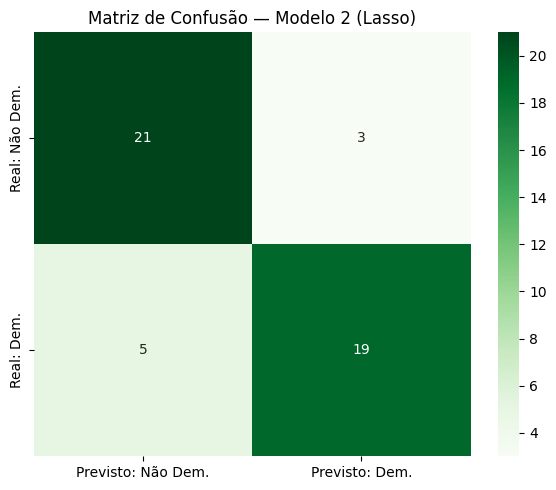

                 precision    recall  f1-score   support

Não Democrático       0.81      0.88      0.84        24
    Democrático       0.86      0.79      0.83        24

       accuracy                           0.83        48
      macro avg       0.84      0.83      0.83        48
   weighted avg       0.84      0.83      0.83        48

Acurácia:  0.8333
AUC:       0.9375


In [ ]:
# Avaliação no conjunto de teste
y_pred_lasso_prob = model_lasso.predict_proba(X_test_scaled)[:, 1]
y_pred_lasso = (y_pred_lasso_prob >= 0.5).astype(int)

auc_lasso = roc_auc_score(y_test_all, y_pred_lasso_prob)
acc_lasso = accuracy_score(y_test_all, y_pred_lasso)
cm_lasso = confusion_matrix(y_test_all, y_pred_lasso)

# Matriz de confusão do Lasso
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lasso, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Previsto: Não Dem.', 'Previsto: Dem.'],
    yticklabels=['Real: Não Dem.', 'Real: Dem.']
)
plt.title('Matriz de Confusão — Modelo 2 (Lasso)')
plt.tight_layout()
plt.show()

print(classification_report(y_test_all, y_pred_lasso, target_names=['Não Democrático', 'Democrático']))
print(f"Acurácia:  {acc_lasso:.4f}")
print(f"AUC:       {auc_lasso:.4f}")

O Modelo 2 apresentou acurácia de 83,3% e AUC de 0,9375 no conjunto de teste, desempenho superior ao do Modelo 1 em ambas as métricas.

A matriz de confusão mostra comportamento ligeiramente assimétrico entre as classes: o modelo identifica países não democráticos com recall de 88% (21 de 24 corretos), enquanto para países democráticos o recall cai a 79% (19 de 24 corretos), sugerindo leve tendência a classificar casos incertos como não democráticos.

As métricas de precisão são equilibradas entre as classes (81% e 86%), e o F1-score de 0,84 para ambas indica desempenho consistente sem viés pronunciado para nenhum grupo.

In [ ]:
# Coeficientes selecionados pelo Lasso
coef_lasso = model_lasso.coef_[0]
tabela_lasso = pd.DataFrame({
    'Variável': relevant_columns,
    'Coeficiente (β pad.)': coef_lasso,
    'Odds Ratio (e^β)': np.exp(coef_lasso)
}).sort_values('Coeficiente (β pad.)', ascending=True)

tabela_lasso['Selecionada?'] = tabela_lasso['Coeficiente (β pad.)'].apply(
    lambda c: 'Sim' if c != 0 else 'Excluida pelo Lasso'
)

print("Coeficientes do Modelo Lasso (na escala padronizada):")
print(tabela_lasso.round(4).to_string(index=False))
print()
selecionadas = tabela_lasso[tabela_lasso['Coeficiente (β pad.)'] != 0]['Variável'].tolist()
print(f"Variáveis selecionadas pelo Lasso ({len(selecionadas)}): {selecionadas}")
print()
print("OBs: Variáveis com coeficiente = 0 foram eliminadas pelo Lasso por não contribuírem significtivamente")

Coeficientes do Modelo Lasso (na escala padronizada):
                        Variável  Coeficiente (β pad.)  Odds Ratio (e^β)        Selecionada?
                personal_freedom               -2.1815            0.1129                 Sim
             natural_environment               -1.0418            0.3528                 Sim
          investment_environment               -0.3016            0.7396                 Sim
           enterprise_conditions               -0.0184            0.9818                 Sim
                  social_capital                0.0000            1.0000 Excluida pelo Lasso
                      governance                0.0000            1.0000 Excluida pelo Lasso
infrastructure_and_market_access                0.0000            1.0000 Excluida pelo Lasso
             safety_and_security                0.0000            1.0000 Excluida pelo Lasso
                economic_quality                0.0000            1.0000 Excluida pelo Lasso
               l

O Lasso zerou 8 das 12 variáveis originais, retendo apenas personal_freedom (β = −2,182), natural_environment (β = −1,042), investment_environment (β = −0,302) e enterprise_conditions (β = −0,018).

A personal_freedom é tem beta maior que o dobro do segundo preditor, concentrando a maior parte do poder discriminatório do modelo.

natural_environment é ainda relevante, sendo o segundo preditor mais forte, mentendo resultado semelhante ao Modelo 1.

As variáveis investment_environment e enterprise_conditions foram mantidas com coeficientes pequenos, indicando contribuição explicativa baixa.

##Comparação entre os Modelos

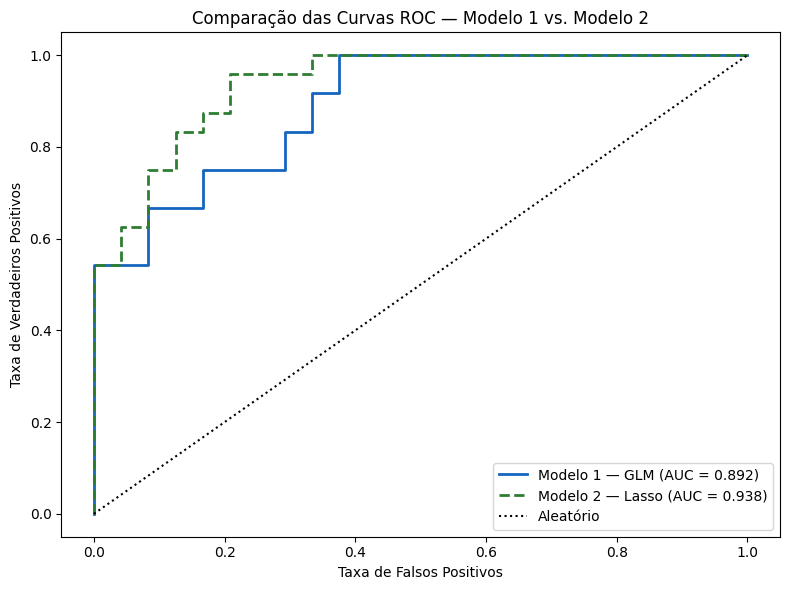

Comparação de Desempenho
          Métrica Modelo 1 — GLM     Modelo 2 — Lasso
         Acurácia         0.7500               0.8333
              AUC         0.8924               0.9375
      N variáveis              7 12 (+ penalidade L1)
Método de seleção     VIF manual   Automática (Lasso)
     Padronização            Não Sim (StandardScaler)


In [ ]:
# Recalcular AUC do Modelo 1
auc_modelo1 = roc_auc_score(y_test, y_pred_prob)
acc_modelo1 = accuracy_score(y_test, y_pred)

fpr2, tpr2, _ = roc_curve(y_test_all, y_pred_lasso_prob)

# Curvas ROC sobrepostas
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1565C0', linewidth=2,
         label=f'Modelo 1 — GLM (AUC = {auc_modelo1:.3f})')
plt.plot(fpr2, tpr2, color='#2E7D32', linewidth=2, linestyle='--',
         label=f'Modelo 2 — Lasso (AUC = {auc_lasso:.3f})')
plt.plot([0, 1], [0, 1], 'k:', label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Comparação das Curvas ROC — Modelo 1 vs. Modelo 2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Tabela comparativa
print("Comparação de Desempenho")
tabela_comp = pd.DataFrame({
    'Métrica': ['Acurácia', 'AUC', 'N variáveis', 'Método de seleção', 'Padronização'],
    'Modelo 1 — GLM': [f'{acc_modelo1:.4f}', f'{auc_modelo1:.4f}', '7', 'VIF manual', 'Não'],
    'Modelo 2 — Lasso': [f'{acc_lasso:.4f}', f'{auc_lasso:.4f}', '12 (+ penalidade L1)', 'Automática (Lasso)', 'Sim (StandardScaler)']
})
print(tabela_comp.to_string(index=False))

O Modelo 1 oferece maior interpretabilidade estatística, fornecendo p-valores, intervalos de confiança e odds ratios na escala original dos dados, o que permite afirmações diretas sobre a significância e magnitude de cada preditor.

Cada melhora de uma posição no ranking de liberdade pessoal está associada a um aumento de 7,3% na chance de o país ser democrático de acordo com o modelo 1.

Já o Modelo 2 apresentou desempenho preditivo superior (precisão de 83,3% vs. 75,0%; AUC de 0,938 vs. 0,892), mas com coeficientes na escala padronizada, sem inferência formal por coeficiente.

A diferença de desempenho reflete condições de estimação distintas em que um modelo  com 12 variáveis originais com padronização, enquanto o GLM operou com 7 variavis sem padronização.

Isso dificulta uma comparação direta, mas para fins de interpretação e inferência, o Modelo 1 é mais adequado, mas para fins de classificação preditiva, o Modelo 2 é superior.

---
## Conclusão

Este trabalho demonstrou a aplicação de Modelos Lineares Generalizados (GLM) na análise de dados sociopolíticos e teve como achados:

Sobre o modelo:
- O GLM Binomial com função Logit é adequado para a variável dependente dicotômica (democrático vs. não democrático)
- O modelo apresentou alto poder discriminatório, com AUC próximo de 0,9 que indica bom poder discriminatório e acurácia de 75% no modelo 1 e 83% no modelo 2.
- O Pseudo R² de McFadden indicou alta qualidade de ajuste

Sobre os preditores:
- Todas as correlações com is_democratic foram negativas, o que é o esperado, as variáveis são rankings, e países democráticos têm rankings melhores (mais baixos)
- A variável com maior poder discriminatório foi liberdade individual para ambos os modelos

O trabalho auxilia na análise de variáveis em diferentes países a partir de indicadores socioeconômicos com relação ao seu regime político, permitindo uma verificação estatítica de premissas de teorias do desenvolvimento que presumem que o desenvolvimento cria mecanismos os quais elevam a democratização do país.

Para melhorar:
Construir modlos sem usar personal_freedom como variavel independente, pois pode ser uma variavel com alta correlação a democracia, pois em países que oferecem maior proteção à liberdade e direitos individuais tem como rede de sua proteção a participação democrática dos indivíduos.  